#ML4Net - Lab 1

## Team members

Àlex Roger Moya (NIA X) | Pau Martínez Carrión (NIA 285580)

## Description

In this lab, you are going to get introduced into Multi-Armed Bandits (MABs) and Wi-Fi simulations. More specifically, you are going to implement a MAB algorithm that performs channel allocation in an Overlapping Basic Service Set (OBSS), i.e., in a scenario where multiple independent BSSs coexist.

## Instructions

*   Follow the steps from this Notebook and complete the proposed exercises.
*   Deliver the completed Notebook by uploading it to your Github repository.
*   Submission deadline: 8 May 2026 (EoB).

## Setting up the environment

1. Connect your Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Download the Simulator's source code

In [2]:
!wget https://github.com/fwilhelmi/fwilhelmi.github.io/raw/refs/heads/master/files/Komondor-lightweight.zip

--2026-05-04 09:31:25--  https://github.com/fwilhelmi/fwilhelmi.github.io/raw/refs/heads/master/files/Komondor-lightweight.zip
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/refs/heads/master/files/Komondor-lightweight.zip [following]
--2026-05-04 09:31:25--  https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/refs/heads/master/files/Komondor-lightweight.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 979661 (957K) [application/zip]
Saving to: ‘Komondor-lightweight.zip’

Komondor-lightweigh 100%[===================>] 956.70K  --.-KB/s    in 0.05s   

3. Define the main path of the code

In [3]:
mypath="drive/MyDrive/AAX/Lab1"

4. Extract the source code

In [4]:
mkdir -p $mypath; cp Komondor-lightweight.zip $mypath; cd $mypath; unzip Komondor-lightweight.zip

Archive:  Komondor-lightweight.zip
replace config_models? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: config_models           
replace learning_modules/ml_model.h? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: learning_modules/ml_model.h  
replace main/traffic_generator.h? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: main/traffic_generator.h  
replace methods/auxiliary_methods.h? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: methods/auxiliary_methods.h  
replace input/agents_monitoring.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: input/agents_monitoring.csv  
replace input/input_nodes.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: input/input_nodes.csv   
replace structures/action.h? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: structures/action.h     
replace main/compcxx_komondor_main.h? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: main/compcxx_komondor_main.h  
replace main/komondor_main.cc? [y]es, [n]o, [A]ll, [

5. Give permissions to run the code

In [5]:
!sudo apt-get install -y lib32stdc++6

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  lib32gcc-s1 libc6-i386
The following NEW packages will be installed:
  lib32gcc-s1 lib32stdc++6 libc6-i386
0 upgraded, 3 newly installed, 0 to remove and 2 not upgraded.
Need to get 3,640 kB of archives.
After this operation, 15.4 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libc6-i386 amd64 2.35-0ubuntu3.13 [2,837 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 lib32gcc-s1 amd64 12.3.0-1ubuntu1~22.04.3 [63.9 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 lib32stdc++6 amd64 12.3.0-1ubuntu1~22.04.3 [739 kB]
Fetched 3,640 kB in 1s (7,049 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 

In [6]:
!cd $mypath; chmod -R 777 .

6. Compile the code

In [7]:
!cd $mypath/main; ./build_local

## How to run simulations

Komondor can be run by calling its compiled main file ("komondor_main") and indicating the value for different flags.

Next, you will see two different ways of running Komondor, depending on whether MAB Agents are instantiated or not.

In any case, **it is important to know** that:


*   Any input files used by the simulator will be located in the `/input` folder.
*   Any output files generated by the simulator will be located in the `/output` folder.

Apart from that, Komondor generates a set of console logs that give meaningful information.


### 1) Simulations without agents

To simulate specific scenarios (described using "input node" files) **without agents**, one must indicate the following flags:

In [15]:
# DEFINE SIMULATION ARGUMENTS (NO AGENTS)

# Path of the file that describes the Wi-Fi nodes
INPUT_FILE_NODES='../input/input_nodes.csv'

# Path of the file where output logs are going to be written
OUTPUT_FILE_LOGS='../output/logs_test.txt'

# Path of the file where output logs are going to be written
SIMULATION_CODE='AAX-LAB1'

# Flag to indicate whether "NODE LOGS" will be written into output files (1) or not (0)
FLAG_SAVE_NODE_LOGS=1

# Flag to indicate whether "SYSTEM LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_SYSTEM_LOGS=1

# Flag to indicate whether "NODE LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_NODE_LOGS=1

# Total simulated time (in seconds)
SIM_TIME=100

# Value of the random seed that initializes the random number generator
SEED=7

In [16]:
# RUN THE SIMULATION

!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS DISABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes.csv
  - agents_enabled: 0
  - script_output_filename: ../output/logs_test.txt
  - simulation_code: AAX-LAB1
  - save_node_logs: 1
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Generating nodes DETERMINISTICALLY through NODES input file...
  - Reading nodes input file '../input/

### 2) Simulations with agents (used for keeping track of temporary performance)

To simulate specific scenarios (described using "input node" files) **with agents**, one must indicate the following flags:

In [44]:
# DEFINE SIMULATION ARGUMENTS (WITH AGENTS FOR MONITORING PERFORMANCE)

# Path of the file that describes the Wi-Fi nodes
INPUT_FILE_NODES='../input/input_nodes.csv'

# Path of the file that describes the agents associated with nodes
#INPUT_FILE_AGENTS='../input/agents_monitoring.csv' #ex2 input agents
#INPUT_FILE_AGENTS  = '../input/agents_egreedy.csv'  #ex3 input agents
INPUT_FILE_AGENTS  = '../input/agents_ml4net.csv'  #ex4 input agents

# Path of the file where output logs are going to be written
OUTPUT_FILE_LOGS='../output/logs_test_agents.txt'

# Path of the file where output logs are going to be written
SIMULATION_CODE='AAX-LAB1-AGENTS'

# Flag to indicate whether "NODE LOGS" will be written into output files (1) or not (0)
FLAG_SAVE_NODE_LOGS=0

# Flag to indicate whether "AGENT LOGS" will be written into output files (1) or not (0)
FLAG_SAVE_AGENT_LOGS=1

# Flag to indicate whether "SYSTEM LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_SYSTEM_LOGS=1

# Flag to indicate whether "NODE LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_NODE_LOGS=1

# Flag to indicate whether "AGENT LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_AGENT_LOGS=1

# Total simulated time (in seconds)
SIM_TIME=100

# Value of the random seed that initializes the random number generator
SEED=7

Run the simulation

In [45]:
!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_ml4net.csv
  - script_output_filename: ../output/logs_test_agents.txt
  - simulation_code: AAX-LAB1-AGENTS
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-AGENTS.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Generating nodes DETERMINIST

## EXERCISES

**All imports used so far:**

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations
import re

### Exercise 1:
Run the simulator (without agents) for the provided input nodes file (`/input/input_nodes.csv`). Before running the simulation, activate the flag that allows saving node logs into a file. After running the simulation, use the information from the log files of each node (e.g., AP_A, STA_A1, AP_B, STA_B1) to plot the scenario. To make the plot, consider the position of the nodes, the channel used, and the power strength that each node perceives from each other node in the deployment.

*Note: To know the power strength perceived by a given device (e.g., AP A) from any other devices (e.g., STA A1, AP B, STA B1), check the logs of that node and identify the cases where other nodes are detected to start/stop a transmission.*

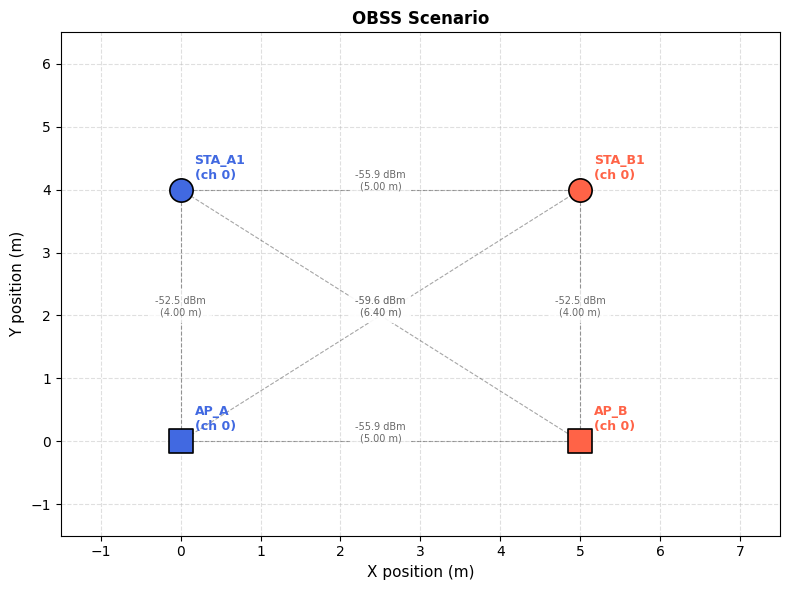

In [17]:
# NODE DATA — hardcoded from the simulator log output
nodes = {
    "AP_A":   {"pos": (0, 0), "channel": 0, "type": "AP",  "wlan": "A"},
    "STA_A1": {"pos": (0, 4), "channel": 0, "type": "STA", "wlan": "A"},
    "AP_B":   {"pos": (5, 0), "channel": 0, "type": "AP",  "wlan": "B"},
    "STA_B1": {"pos": (5, 4), "channel": 0, "type": "STA", "wlan": "B"},
}

# ─────────────────────────────────────────────────────────
# PATH LOSS MODEL 4 (log-distance, 5 GHz)
# Used by Komondor to compute received signal strength
# TX power = 15 dBm, path loss exponent n = 3.5
# ─────────────────────────────────────────────────────────
def received_power_dBm(d, tx_dBm=15.0, n=3.5, f_GHz=5.0):
    # Free-space path loss at 1m reference (dB)
    pl_ref = 20 * np.log10(4 * np.pi * f_GHz * 1e9 / 3e8)
    # Total path loss at distance d
    pl = pl_ref + 10 * n * np.log10(max(d, 0.001))
    return tx_dBm - pl

# PLOT ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

wlan_colors = {"A": "royalblue", "B": "tomato"}

# --- Draw power lines between every pair of nodes ---
for n1, n2 in combinations(nodes.keys(), 2):
    x1, y1 = nodes[n1]["pos"]
    x2, y2 = nodes[n2]["pos"]
    d = np.sqrt((x2-x1)**2 + (y2-y1)**2)   # Euclidean distance
    pwr = received_power_dBm(d)

    ax.plot([x1, x2], [y1, y2], "k--", lw=0.8, alpha=0.35)

    # Label at midpoint: perceived power and distance
    mx, my = (x1+x2)/2, (y1+y2)/2
    ax.text(mx, my, f"{pwr:.1f} dBm\n({d:.2f} m)",
            fontsize=7, color="dimgray", ha="center",
            bbox=dict(fc="white", ec="none", alpha=0.7))

# --- Draw nodes ---
for name, info in nodes.items():
    x, y  = info["pos"]
    color = wlan_colors[info["wlan"]]
    # Square marker for AP, circle for STA
    marker = "s" if info["type"] == "AP" else "o"

    ax.scatter(x, y, color=color, marker=marker,
               s=280, zorder=5, edgecolors="black", linewidths=1.2)
    ax.annotate(f'{name}\n(ch {info["channel"]})',
                (x, y), textcoords="offset points",
                xytext=(10, 8), fontsize=9,
                fontweight="bold", color=color)

ax.set_xlim(-1.5, 7.5)
ax.set_ylim(-1.5, 6.5)
ax.set_xlabel("X position (m)", fontsize=11)
ax.set_ylabel("Y position (m)", fontsize=11)
ax.set_title("OBSS Scenario",fontsize=12, fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("exercise1_scenario.png", dpi=150)
plt.show()

### Exercise 2:

Run the simulator (this time, with agents in "monitor" mode) for the provided input nodes file (`/input/input_nodes.csv`). The input agents file to be used is provided as (`/input/agents_monitoring.csv`). Ensure that the agent logs are saved into files by setting the corresponding flag to 1. After running the simulation, use the agent log files to plot the temporary throughput obtained by each AP.

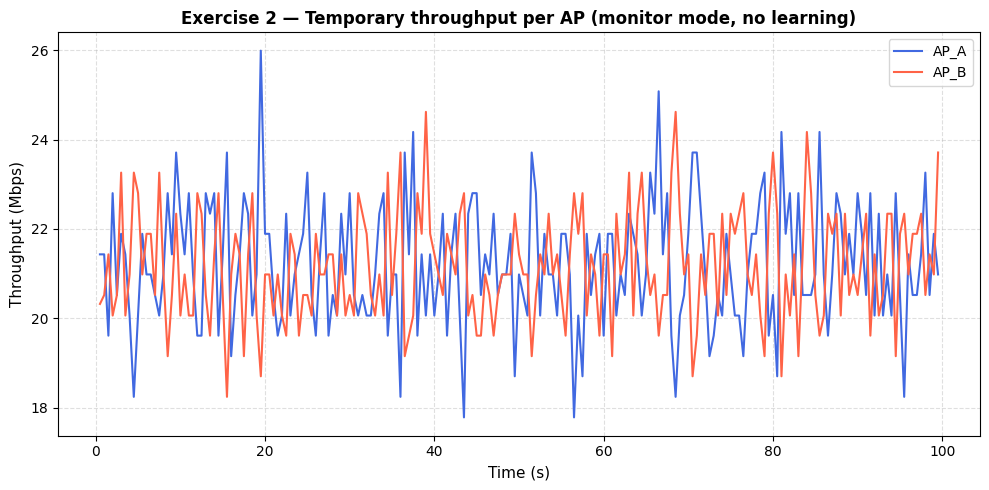

In [31]:
def parse_agent_log(filepath):
    #Reads a Komondor agent log and extracts time + throughput.
    times = []
    throughputs = []
    #Each line with 'Average throughput' looks like: 0.500;A0;C03; Average throughput = 21.43 Mbps
    with open(filepath, 'r') as f:
        for line in f:
            # Find lines containing throughput measurements
            match = re.search(r'^([\d.]+);.*Average throughput = ([\d.]+) Mbps', line)
            if match:
                times.append(float(match.group(1)))       # first field = simulation time
                throughputs.append(float(match.group(2))) # second capture = Mbps value

    return times, throughputs

# Parse log files for both agents (A0 = AP_A, A1 = AP_B)
times_A, thr_A = parse_agent_log(f'{mypath}/output/logs_output_AAX-LAB1-AGENTS_A0_A.txt')
times_B, thr_B = parse_agent_log(f'{mypath}/output/logs_output_AAX-LAB1-AGENTS_A1_B.txt')

# ── PLOT ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(times_A, thr_A, color='royalblue', linewidth=1.5, label='AP_A')
ax.plot(times_B, thr_B, color='tomato',    linewidth=1.5, label='AP_B')
ax.set_xlabel('Time (s)', fontsize=11)
ax.set_ylabel('Throughput (Mbps)', fontsize=11)
ax.set_title('Exercise 2 — Temporary throughput per AP (monitor mode, no learning)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{mypath}/output/exercise2_throughput.png', dpi=150)
plt.show()

**Explication:** Both APs share channel 0 → they interfere with each other → each gets ~50% of the channel. Since agents are in MONITOR mode: they only observe throughput, they never change channel.
Thus both lines fluctuate around ~21 Mbps with no improvement over time.

### Exercise 3:

Copy the `agents_monitoring.csv` file, rename it as `agents_egreedy.csv`, and modify it as follows:
- Indicate the possible "channel actions" by indicating `0,1` in the column 'actions channels' of each agent.
- Set the colum "learning mechanism" to `1`(which stands for multi-armed bandits) for each agent.
- Set the column "selected strategy" to `1` (which stands for ɛ-greedy) for each agent.

Then, run the simulation using `agents_egreedy.csv` and plot the temporary throughput obtained by each AP, as done in Exercise 2. In addition, read the console logs from Komondor and explain the displayed agent logs.

**Important:** In case of experiencing a run-time error, check that the fields in the 'agents' file are separated by a semicolon (`;`).

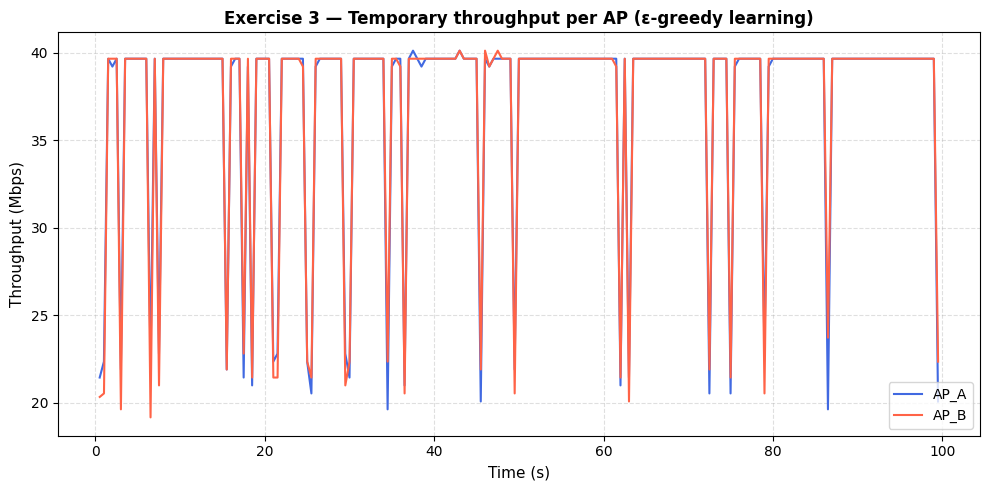

In [38]:
# Agent should learn so increasing performance
def parse_agent_log(filepath):
    #extract time and throughput from Komondor agent log file
    times, throughputs = [], []
    with open(filepath, 'r') as f:
        for line in f:
            match = re.search(r'^([\d.]+);.*Average throughput = ([\d.]+) Mbps', line)
            if match:
                times.append(float(match.group(1)))
                throughputs.append(float(match.group(2)))
    return times, throughputs

# Agent log files will be named with the new simulation code AAX-LAB1-EGREEDY
times_A, thr_A = parse_agent_log(f'{mypath}/output/logs_output_AAX-LAB1-AGENTS_A0_A.txt')
times_B, thr_B = parse_agent_log(f'{mypath}/output/logs_output_AAX-LAB1-AGENTS_A1_B.txt')

# PLOT ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(times_A, thr_A, color='royalblue', linewidth=1.5, label='AP_A')
ax.plot(times_B, thr_B, color='tomato',    linewidth=1.5, label='AP_B')

ax.set_xlabel('Time (s)', fontsize=11)
ax.set_ylabel('Throughput (Mbps)', fontsize=11)
ax.set_title('Exercise 3 — Temporary throughput per AP (ε-greedy learning)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{mypath}/output/exercise3_throughput.png', dpi=150)
plt.show()

**Explication:** Agents now use e-greedy: they TRY different channels and LEARN which one is best. At the start, throughput may be unstable (exploration phase). Over time, each AP should converge to a different channel → throughput improves.
Notice that:
  - 40 Mbps = AP found a free channel (no interference)
  - 21 Mbps = both APs on same channel (interference, 50% throughput)

We can see that agent tries the other channel to see if it's better so agents act independently → sometimes both pick the same channel → both drop



### Exercise 4:
Create another input agents file (name it `agents_ml4net.csv`), but this time set the column "selected_strategy" (the last one) to 5.

The mechanism (as it is currently implemented) will just select actions randomly. For that reason, you have to define your own action-selection strategy by completing the code in `/learning_modules/network_optimization_methods/multi_armed_bandits.h`. More specifically, you will have to complete the function `PickArmML4Net()`, which contains all the logic. You can get inspiration from the other implemented MAB algorithms (e.g., UCB, Thompson sampling).

**IMPORTANT:** If you modify the source code, you will have to re-compile it (see step 6 in "Setting up the environment") before running new simulations.


int PickArmML4Net(int num_arms) {
          
          // UCB strategy: pick the arm with highest average reward + exploration bonus
          // Bonus = sqrt(2 * log(total_tries) / tries_for_this_arm)
          // Arms never tried get infinite score → always explored first

          int action_ix = 0;
          double max_score = -1e9;

          for (int i = 0; i < num_arms; ++i) {
              double score;
              if (times_arm_has_been_selected[i] == 0) {
                  // Arm never tried → explore it first (infinite priority)
                  score = 1e9;
              } else {
                  //score: exploit (average reward) + explore (bonus for less-tried arms)
                  score = average_reward_per_arm[i] +
                          sqrt((2.0 * log((double)num_iterations)) /
                              (double)times_arm_has_been_selected[i]);
              }
              if (score > max_score) {
                  max_score = score;
                  action_ix = i;
              }
          }
          return action_ix;
}

In [ ]:
#CREATE agents_ml4net.csv ──────────────────────────────────────
# Same as egreedy but selected_strategy = 5 (our UCB implementation)
with open(f'{mypath}/input/agents_ml4net.csv', 'w') as f:
    f.write("Wlan code;centralized;time between requests (seconds);actions channels;actions cca (dBm);actions tx power (dBm);max_bw;reward;learning mechanism;selected_strategy\n")
    f.write("A;0;0.5;0,1;-82;15;1;2;1;5\n")
    f.write("B;0;0.5;0,1;-82;15;1;2;1;5\n")

print("agents_ml4net.csv created!")

**EXPLICATION OF THE STRATEGY:** The idea is simple: pick the channel that looks best, but try unfamiliar channels more often.
Every round, each agent scores each channel as:
score = average_reward + sqrt(2 · log(total_tries) / tries_for_this_channel)

Left part → exploit: prefer channels with high past reward
Right part → explore: bonus for channels tried few times, shrinks as you try them more

No randomness — pure math. Once the agents learn that different channels are better, they stick to them permanently. This gives ~40 Mbps stable from second 2, vs ε-greedy which keeps dropping randomly throughout the simulation.

### Exercise 5:

Run a simulation to test your action-selection strategy. Compare it to ɛ-greedy (Exercise 3) by plotting the temporary throughput obtained by each of the mechanisms.

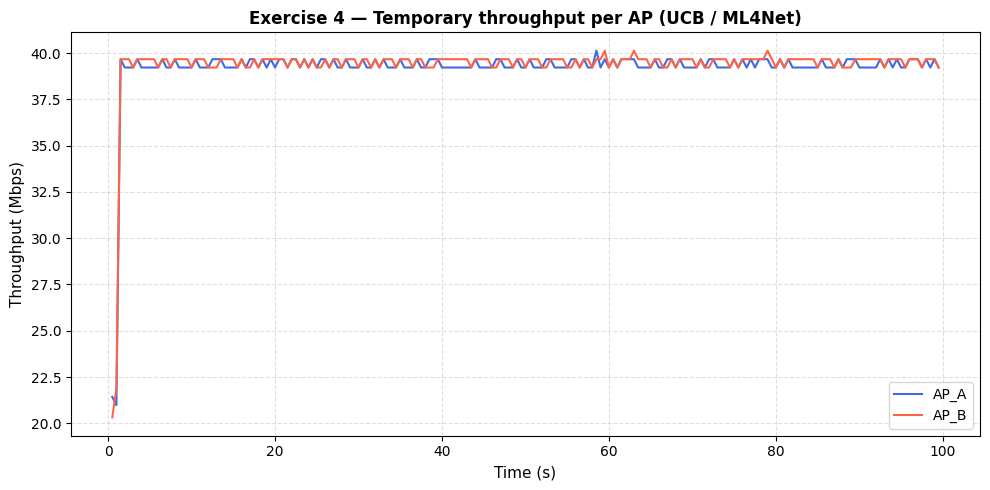

In [48]:
# PARSE AND PLOT THROUGHPUT ─────────────────────────────────────

def parse_agent_log(filepath):
    """Extract time and throughput from Komondor agent log file"""
    times, throughputs = [], []
    with open(filepath, 'r') as f:
        for line in f:
            match = re.search(r'^([\d.]+);.*Average throughput = ([\d.]+) Mbps', line)
            if match:
                times.append(float(match.group(1)))
                throughputs.append(float(match.group(2)))
    return times, throughputs

# Parse ML4Net agent logs (named with simulation code AAX-LAB1-ML4NET)
times_A, thr_A = parse_agent_log(f'{mypath}/output/logs_output_AAX-LAB1-AGENTS_A0_A.txt')
times_B, thr_B = parse_agent_log(f'{mypath}/output/logs_output_AAX-LAB1-AGENTS_A1_B.txt')

# ── PLOT ───────────────────────────────────────────────────────────────────
# UCB explores every arm first, then exploits the best one
# Expect faster convergence and fewer drops than e-greedy

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(times_A, thr_A, color='royalblue', linewidth=1.5, label='AP_A')
ax.plot(times_B, thr_B, color='tomato',    linewidth=1.5, label='AP_B')

ax.set_xlabel('Time (s)', fontsize=11)
ax.set_ylabel('Throughput (Mbps)', fontsize=11)
ax.set_title('Exercise 4 — Temporary throughput per AP (UCB / ML4Net)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{mypath}/output/exercise4_throughput.png', dpi=150)
plt.show()

### Exercise 6:

Now, modify the "input_nodes.csv" and the input agent files (`agents_egreedy.csv` and `agents_ml4net.csv`) to add a third BSS, which must use the same configuration as the other BSSs but whose AP and STA must be placed at (10,0,0) m and (10,4,0) m, respectively. In the agents file, you will also have to add a third column so that the third BSS gets an agent enrolled.

Run N=5 simulations (using different random seeds) for each action-selection strategy and plot the average throughput obtained by each BSS across the different simulations for each approach.

In [ ]:
# (response to exercise 6)